<a href="https://colab.research.google.com/github/EMADUDDINAsdaq/retinal-cyst-segmentation/blob/main/notebooks/Retinal_Cyst_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Imports libraries, mount Drive, and drive Paths to image data set
import os
import numpy as np
import matplotlib.pyplot as plt

from skimage import io, exposure
from skimage.filters import threshold_otsu, gaussian, threshold_local
from skimage.feature import canny, peak_local_max
from skimage.morphology import (
    disk, binary_opening, binary_closing, remove_small_objects
)
from skimage.filters.rank import entropy
from skimage.segmentation import watershed
from skimage.measure import label, regionprops
from skimage.transform import resize
from skimage.color import gray2rgb
from skimage.exposure import rescale_intensity
from scipy.ndimage import median_filter, binary_fill_holes, distance_transform_edt
from sklearn.cluster import KMeans
from sklearn.metrics import jaccard_score
from scipy.spatial.distance import dice
from google.colab import drive
drive.mount('/content/drive')
# --- Dataset & results directories  ---
img_dir = '/content/drive/My Drive/Assignment/OCT_Dataset/img_dir'
ann_dir = '/content/drive/My Drive/Assignment/OCT_Dataset/ann_dir'
res_dir = '/content/drive/My Drive/Assignment/OCT_Results'
os.makedirs(res_dir, exist_ok=True)
print("Environment ready — all paths set.")
print("   img_dir:", img_dir)
print("   ann_dir:", ann_dir)
print("   res_dir:", res_dir)

Mounted at /content/drive
Environment ready — all paths set.
   img_dir: /content/drive/My Drive/Assignment/OCT_Dataset/img_dir
   ann_dir: /content/drive/My Drive/Assignment/OCT_Dataset/ann_dir
   res_dir: /content/drive/My Drive/Assignment/OCT_Results


In [ ]:
# Define All Core Functions
# Phase 1 & 2: Preprocessing + ROI mask
def preprocess_image(img_path):
    """
    Phase 0–2:
    - Read OCT
    - Normalize to [0,255] for reading into skimage
    - Median + Gaussian smoothing
    """
    im = io.imread(img_path).astype(np.float32)
    im = 255 * (im - im.min()) / (im.max() - im.min() + 1e-8)

    # Phase 1: smoothing
    im_median  = median_filter(im, size=3)
    im_gaussian = gaussian(im, sigma=1, preserve_range=True)

    return im, im_median, im_gaussian

def extract_roi(im_gaussian):
    """
    Phase 2A + binary_fill_holes:
    - Otsu threshold
    - Canny edges + central vertical band prior
    - retina_mask_otsu
    - binary_fill_holes on Otsu mask
    - masked_retina: everything outside filled mask = 0
    """
    central_band = (80, 300)      # rows [y1, y2] expected to contain retina
    edge_low, edge_high = 0.1, 0.3

    # Otsu global threshold on Gaussian-smoothed image
    t = threshold_otsu(im_gaussian)
    mask_otsu = im_gaussian > t

    # Edge map (not directly used in mask, but same logic as notes)
    edges = canny(im_gaussian / 255.0,
                  low_threshold=edge_low,
                  high_threshold=edge_high)

    # Band prior — restrict to vertical strip where retina lives
    edge_band = np.zeros_like(mask_otsu, dtype=bool)
    y1, y2 = central_band
    edge_band[y1:y2, :] = True

    retina_mask_otsu = mask_otsu & edge_band

    # Fill the interior region enclosed by Otsu mask
    retina_mask_filled = binary_fill_holes(retina_mask_otsu)

    # Apply mask — everything outside ROI is black
    masked_retina = np.zeros_like(im_gaussian)
    masked_retina[retina_mask_filled] = im_gaussian[retina_mask_filled]

    return masked_retina, retina_mask_filled



In [ ]:
# Phase 3: Cyst enhancement
def cyst_enhancement(masked_retina, retina_mask_filled):
    """
    Phase 3 — Cyst enhancement inside ROI [1]:
    - Contrast stretch [P2,P98] inside ROI → [0,255]
    - Light Gaussian smoothing σ=0.6
    """
    roi_mask = retina_mask_filled.astype(bool)

    # percentiles inside ROI
    roi_vals = masked_retina[roi_mask]
    p2, p98 = np.percentile(roi_vals, (1, 99))

    # Contrast stretch within ROI
    enhanced = masked_retina.copy()
    enhanced[roi_mask] = rescale_intensity(
        masked_retina[roi_mask],
        in_range=(p2, p98),
        out_range=(0, 255)
    )

    # Light smoothing (structure-preserving)
    enhanced_sm = gaussian(enhanced, sigma=0.6, preserve_range=True)

    return enhanced_sm



In [ ]:
def detect_cysts_phase4(enhanced_sm, retina_mask_filled):
    roi_mask = retina_mask_filled.astype(bool)
    base_img = enhanced_sm.copy()

    # Step 1 — CLAHE inside ROI
    clahe_img = np.zeros_like(base_img, dtype=np.float32)
    clahe_img[roi_mask] = (
        exposure.equalize_adapthist(
            np.clip(base_img[roi_mask] / 255.0, 0.0, 1.0),
            clip_limit=0.02
        ) * 255.0
    )

    # Step 2 — Darkest 12%
    roi_vals = clahe_img[roi_mask]
    p_dark = np.percentile(roi_vals, 12)
    dark_mask = (clahe_img <= p_dark) & roi_mask

    # Step 3 — Local thresholding (SAFE VERSION)
    clahe_norm = np.clip(clahe_img / 255.0, 0.0, 1.0).astype(np.float64)

    temp = np.zeros_like(clahe_norm)
    temp[roi_mask] = clahe_norm[roi_mask]

    block_size = 35
    offset = 0.03

    local_thresh = threshold_local(temp, block_size, offset=offset)

    binary_cyst = (clahe_norm < local_thresh) & dark_mask

    # Step 4 — Morphology
    binary_cyst = binary_opening(binary_cyst, disk(2))
    binary_cyst = binary_closing(binary_cyst, disk(3))
    binary_cyst = remove_small_objects(binary_cyst, min_size=20)

    # Output
    final_cyst_mask = np.zeros_like(base_img, dtype=np.uint8)
    final_cyst_mask[binary_cyst] = 255

    return final_cyst_mask


In [ ]:
# Phase 5: Entropy Filter + Watershed + Evaluation
def refine_and_evaluate_phase5(enhanced_sm, final_cyst_mask, retina_mask_filled, ground_truth):
    """
    Phase 5 — Entropy Filter + Fine Segmentation + Evaluation :
    - Entropy map (disk r=3)
    - Keep low-entropy regions (ent < 5.5) ∧ cyst_candidates
    - Distance transform + peak_local_max + watershed
    - Opening + closing + remove_small_objects
    - Compute Dice & IoU with ground truth
    Returns:
      final_mask (bool),
      dice_score (float),
      iou_score (float),
      gt_resized (bool) used for metrics/visualization
    """
    roi_mask = retina_mask_filled.astype(bool)
    base_image = enhanced_sm
    cyst_candidates = final_cyst_mask > 0

    # Resize ground truth to match image shape
    gt_resized = resize(ground_truth, base_image.shape, anti_aliasing=False) > 0.5

    # Step 1: Entropy filtering (low texture → cysts)
    ent = entropy((base_image / base_image.max() * 255).astype(np.uint8), disk(3))
    entropy_thresh = 5.5  # keep 5.5 as in your Version A
    entropy_mask = (ent < entropy_thresh) & cyst_candidates

    # Step 2: Watershed refinement (split merged cysts)
    distance = distance_transform_edt(entropy_mask)
    coords = peak_local_max(distance, min_distance=2, labels=entropy_mask)
    markers = np.zeros_like(entropy_mask, dtype=int)
    if coords.size > 0:
        markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)
    labels_ws = watershed(-distance, markers, mask=entropy_mask)

    # Step 3: Morphological cleaning
    final_mask = labels_ws > 0
    final_mask = binary_opening(final_mask, disk(2))
    final_mask = binary_closing(final_mask, disk(3))
    final_mask = remove_small_objects(final_mask, min_size=15)

    # Step 4: Metrics (Dice, IoU)
    gt_flat = gt_resized.flatten().astype(int)
    pred_flat = final_mask.flatten().astype(int)

    iou_score = jaccard_score(gt_flat, pred_flat)
    dice_score = 1 - dice(gt_flat, pred_flat)

    return final_mask, dice_score, iou_score, gt_resized


=== Processing Image TRAINING1.tif ===
Saved predicted mask to: /content/drive/My Drive/Assignment/OCT_Results/TRAINING1.tif
Dice=0.3831, IoU=0.2370


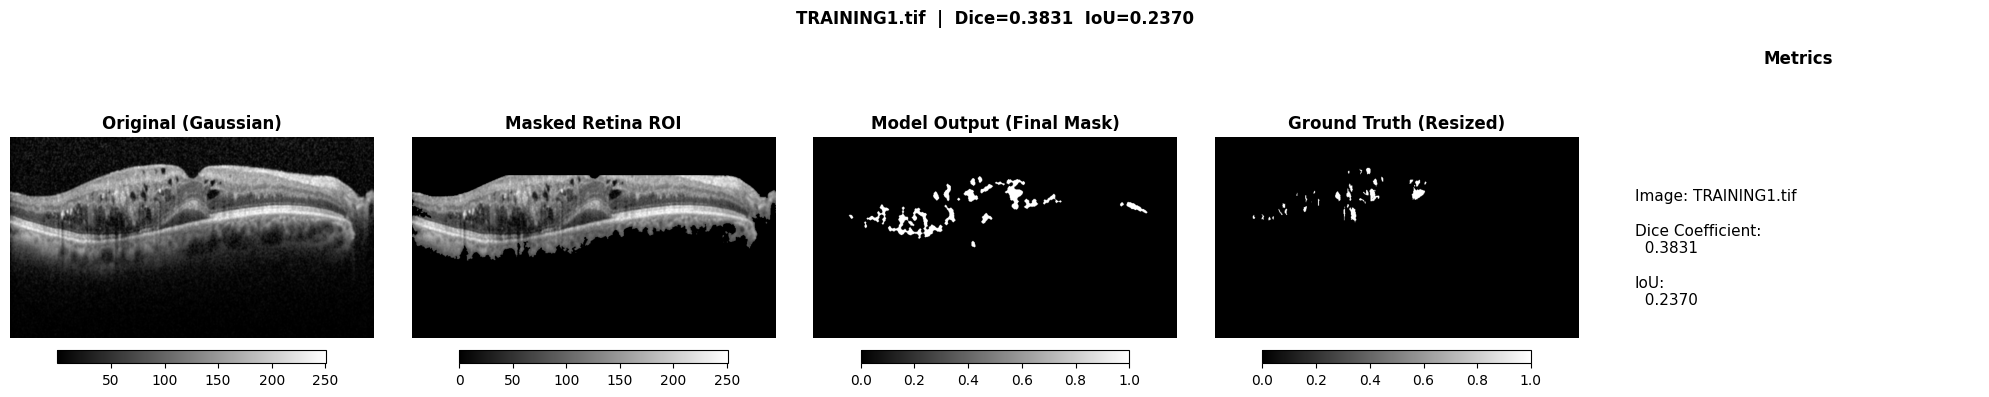


=== Processing Image TRAINING2.tif ===
Saved predicted mask to: /content/drive/My Drive/Assignment/OCT_Results/TRAINING2.tif
Dice=0.5771, IoU=0.4056


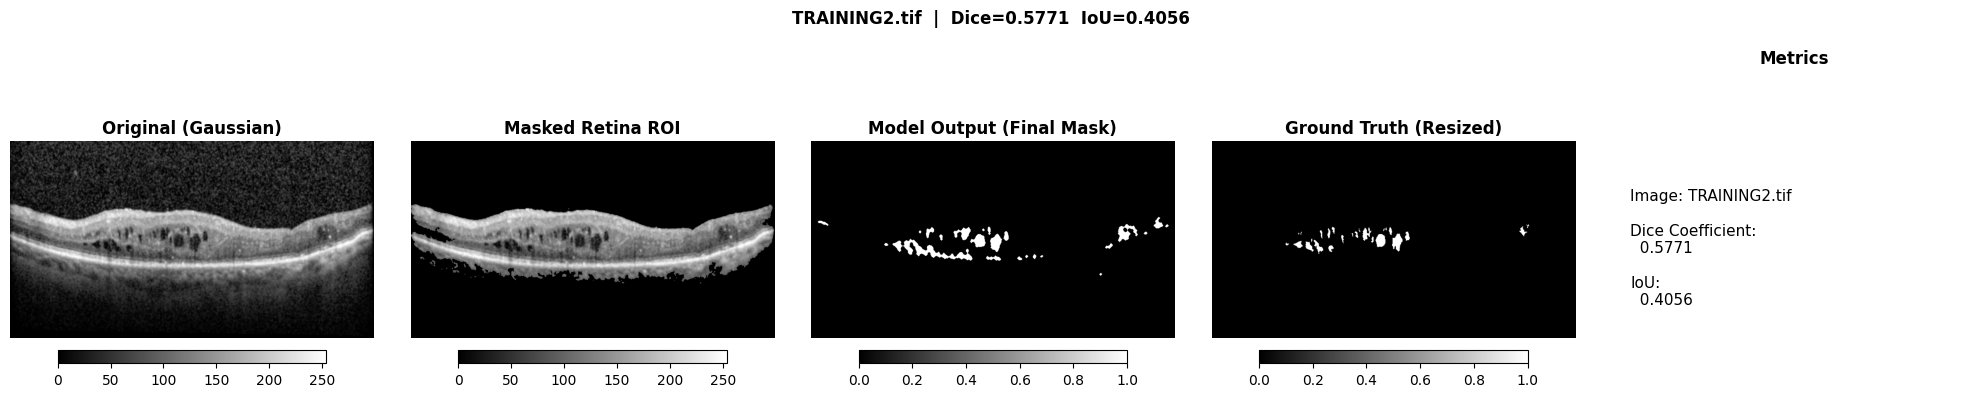


=== Processing Image TRAINING3.tif ===
Saved predicted mask to: /content/drive/My Drive/Assignment/OCT_Results/TRAINING3.tif
Dice=0.0557, IoU=0.0286


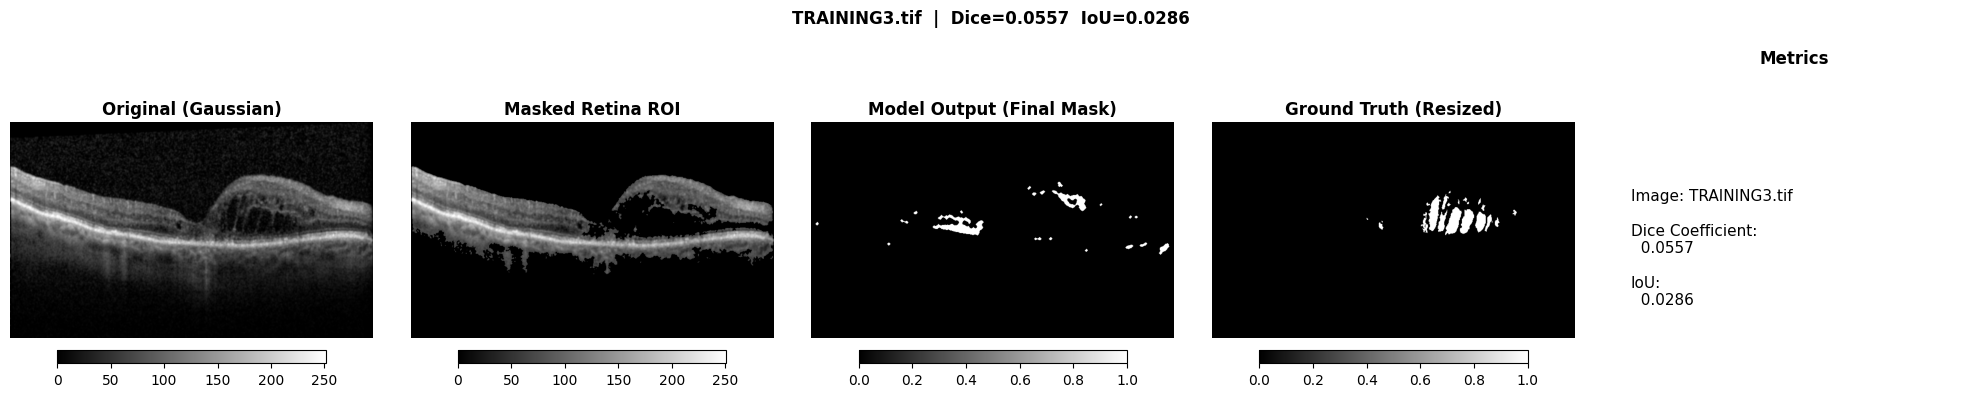


=== Processing Image TRAINING4.tif ===
Saved predicted mask to: /content/drive/My Drive/Assignment/OCT_Results/TRAINING4.tif
Dice=0.5983, IoU=0.4268


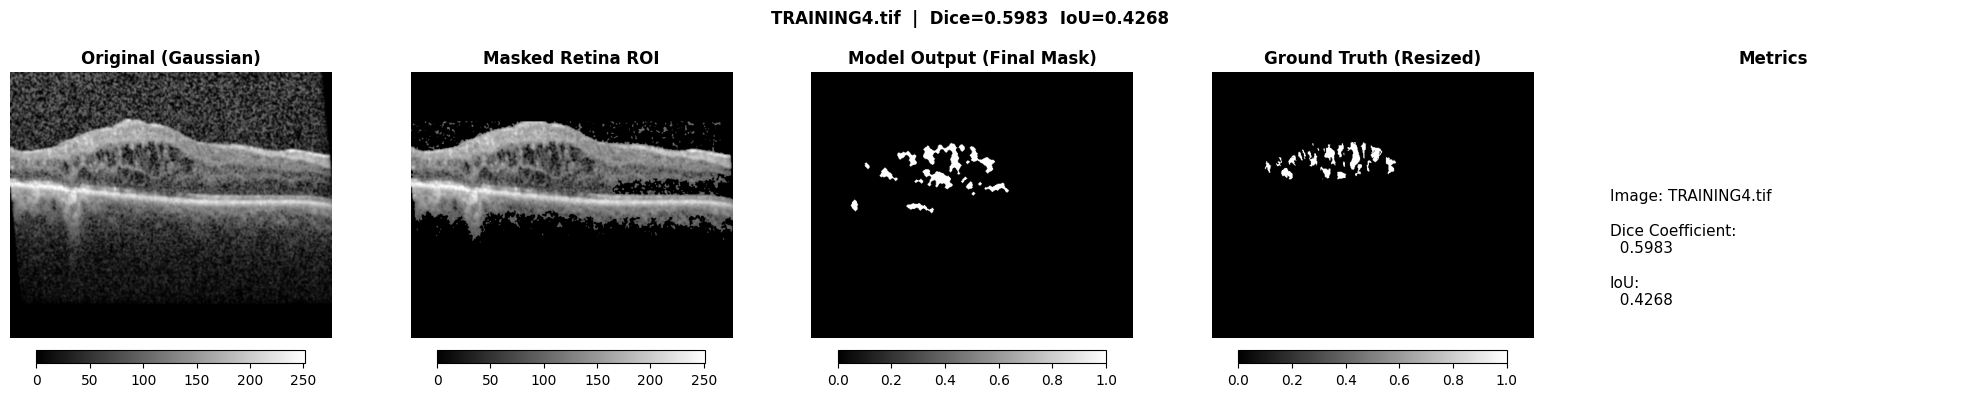


=== Processing Image TRAINING5.tif ===
Saved predicted mask to: /content/drive/My Drive/Assignment/OCT_Results/TRAINING5.tif
Dice=0.5398, IoU=0.3697


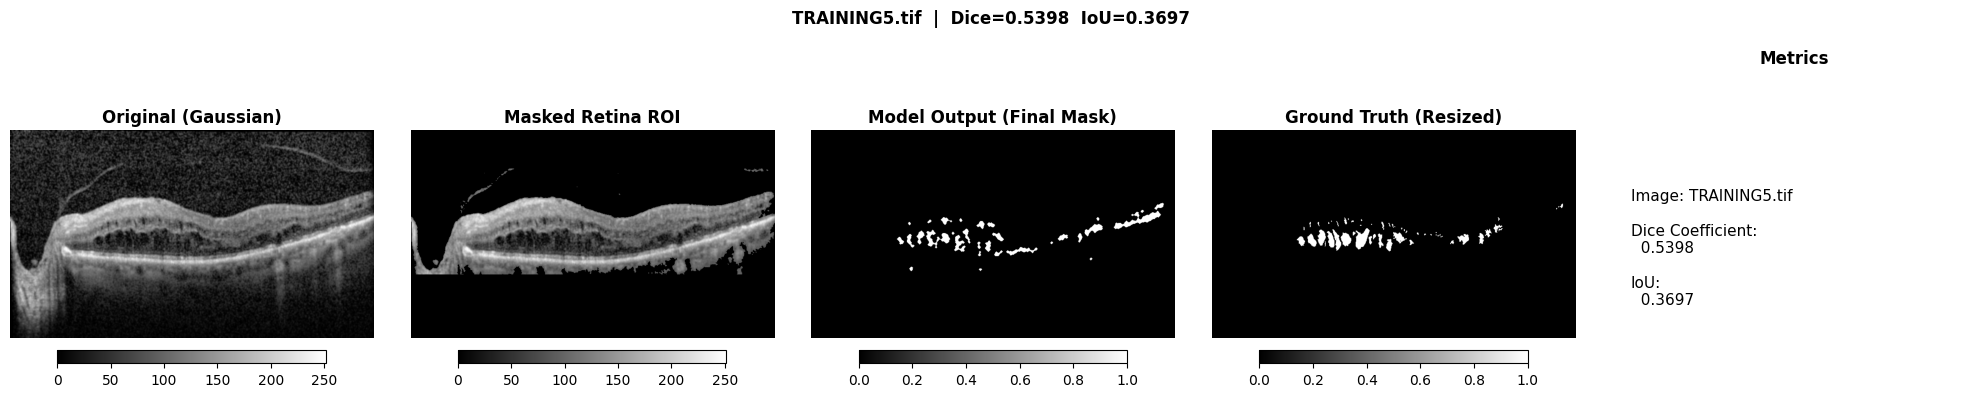


=== Processing Image TRAINING6.tif ===
Saved predicted mask to: /content/drive/My Drive/Assignment/OCT_Results/TRAINING6.tif
Dice=0.5208, IoU=0.3521


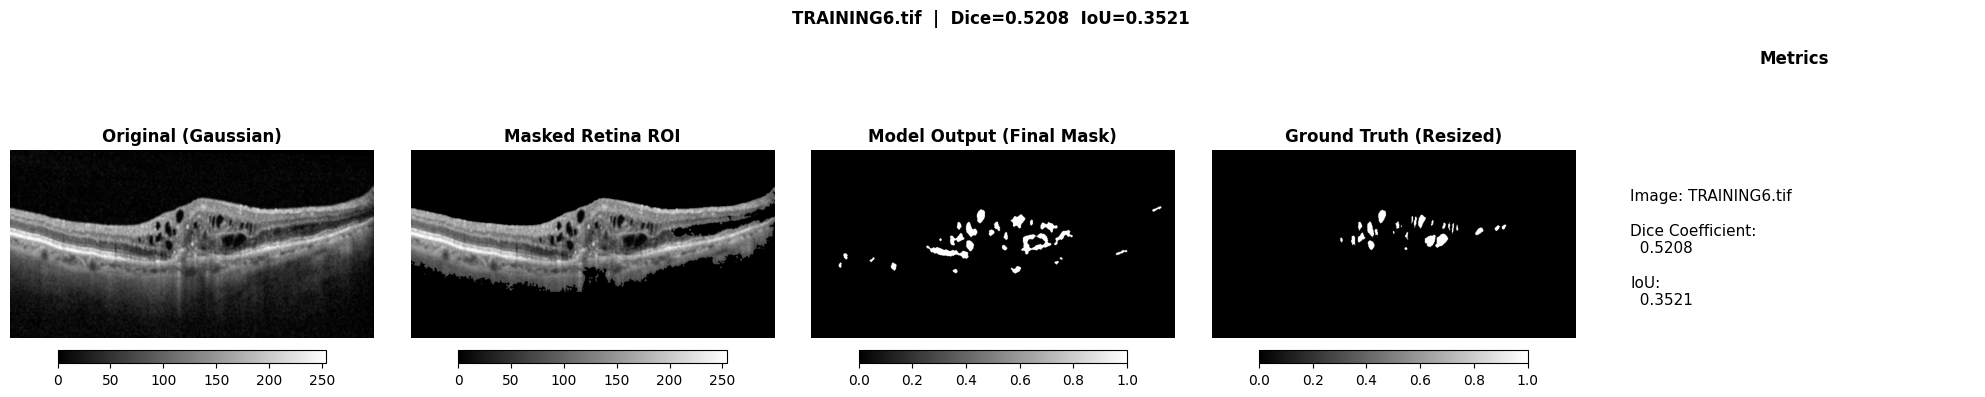


=== Processing Image TRAINING7.tif ===


/usr/local/lib/python3.12/dist-packages/skimage/_shared/utils.py:328: UserWarning: /content/drive/My Drive/Assignment/OCT_Results/TRAINING7.tif is a low contrast image
  return func(*args, **kwargs)


Saved predicted mask to: /content/drive/My Drive/Assignment/OCT_Results/TRAINING7.tif
Dice=0.1519, IoU=0.0822


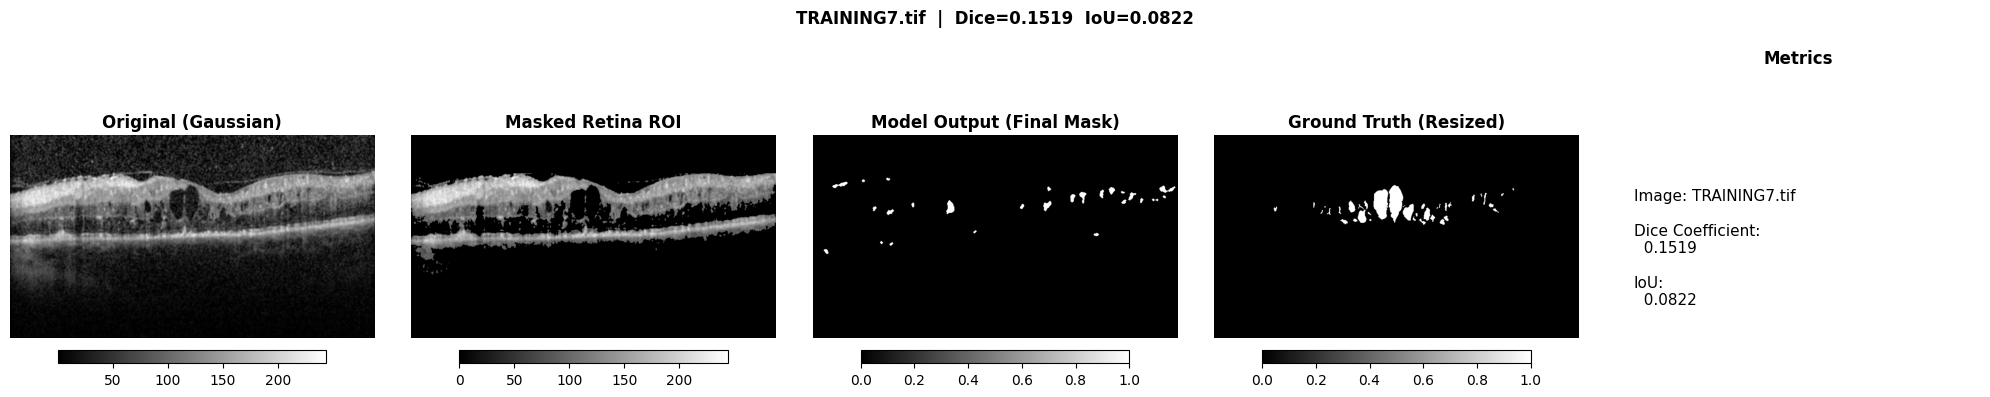


=== Processing Image TRAINING8.tif ===
Saved predicted mask to: /content/drive/My Drive/Assignment/OCT_Results/TRAINING8.tif
Dice=0.5737, IoU=0.4022


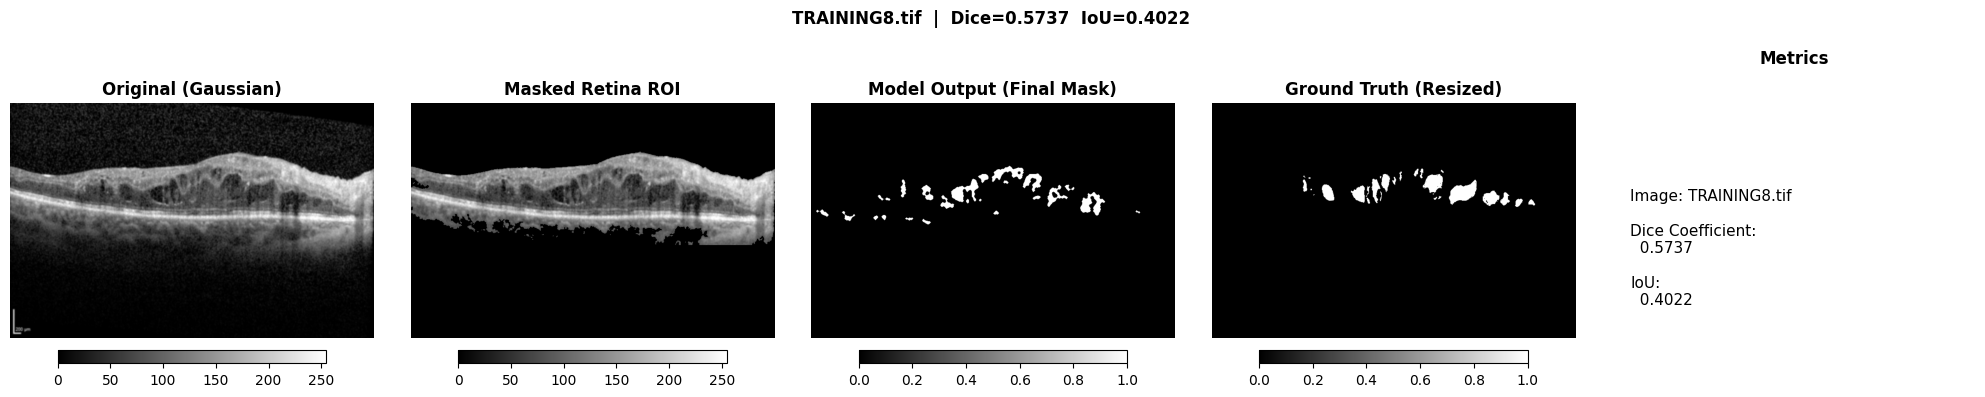


=== Processing Image TRAINING9.tif ===
Saved predicted mask to: /content/drive/My Drive/Assignment/OCT_Results/TRAINING9.tif
Dice=0.2690, IoU=0.1554


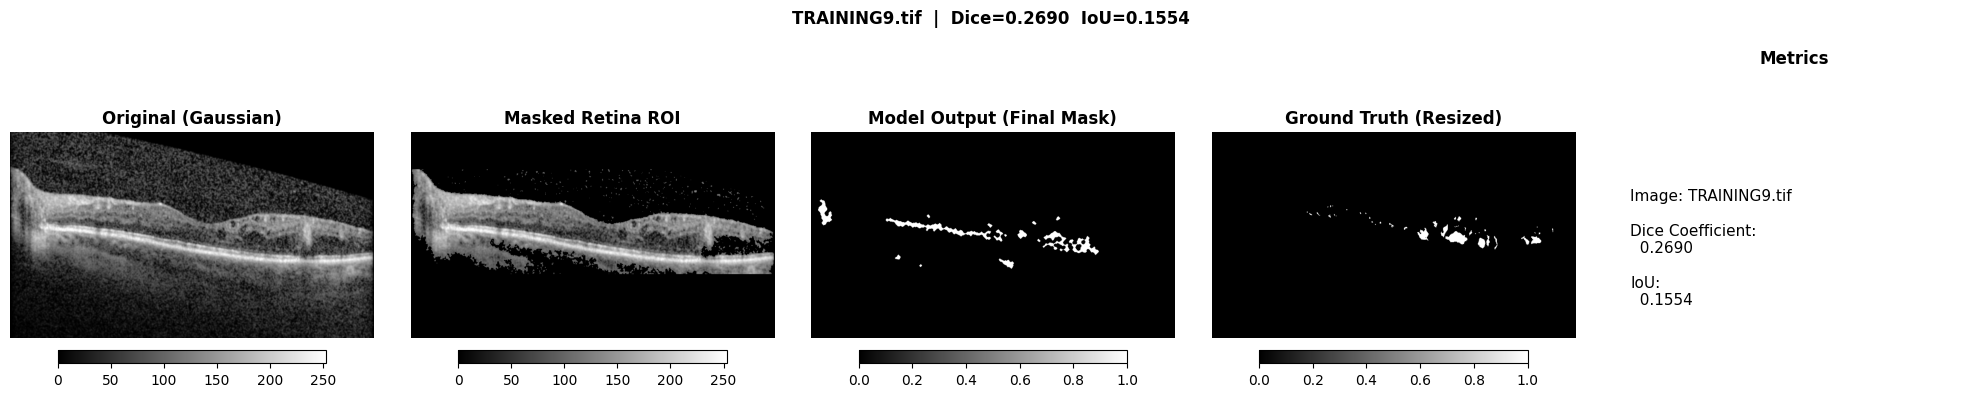


=== Processing Image TRAINING10.tif ===
Saved predicted mask to: /content/drive/My Drive/Assignment/OCT_Results/TRAINING10.tif
Dice=0.4846, IoU=0.3198


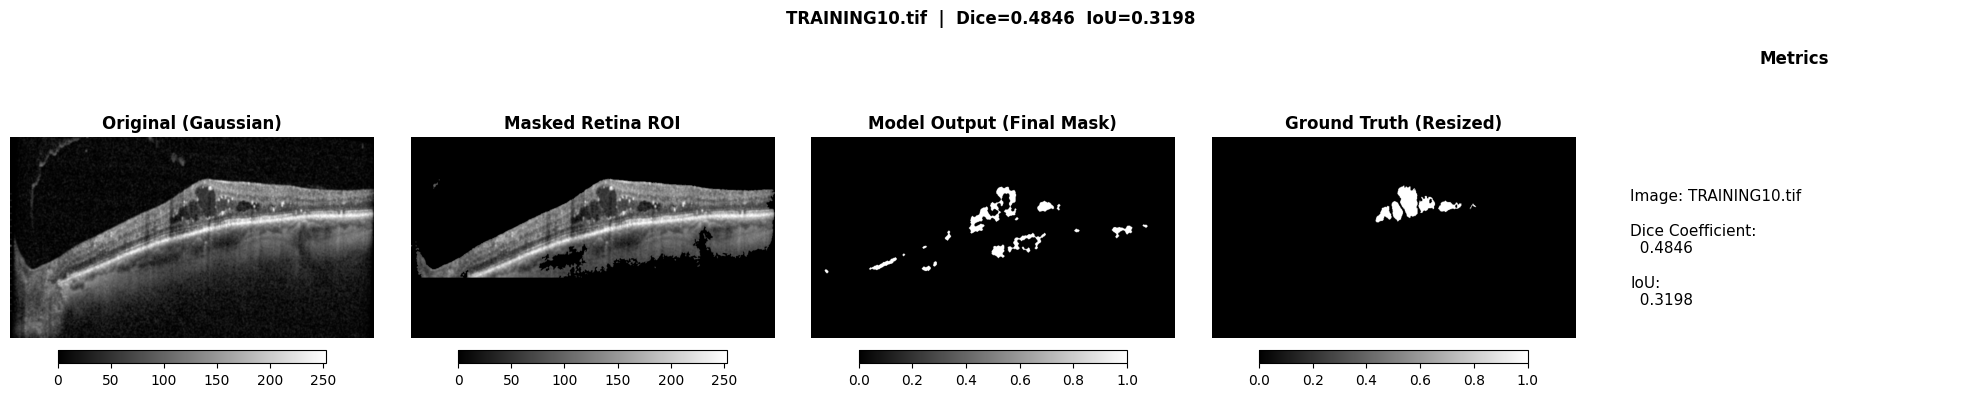


 Processing complete — all results saved to res_dir and visualized.


In [ ]:
# CELL 3 — Main Loop over Dataset (TRAINING1–10)
results = []

for i in range(1, 11):
    img_name = f"TRAINING{i}.tif"
    print(f"\n=== Processing Image {img_name} ===")

    # --- Paths for this image ---
    img_path = os.path.join(img_dir, img_name)
    gt_path  = os.path.join(ann_dir,  img_name)

    # --- Phase 1–2: Preprocessing + ROI ---
    im, im_median, im_gaussian = preprocess_image(img_path)
    masked_retina, retina_mask_filled = extract_roi(im_gaussian)

    # --- Phase 3: Cyst Enhancement ---
    enhanced_sm = cyst_enhancement(masked_retina, retina_mask_filled)

    # --- Phase 4: Initial Cyst Detection (final_cyst_mask) ---
    final_cyst_mask = detect_cysts_phase4(enhanced_sm, retina_mask_filled)

    # --- Phase 5: Entropy + Watershed + Evaluation ---
    gt_raw = io.imread(gt_path, as_gray=True)
    refined_mask, dice_score, iou_score, gt_resized = refine_and_evaluate_phase5(
        enhanced_sm, final_cyst_mask, retina_mask_filled, gt_raw
    )

    # --- Save final mask as .tif in res_dir ---
    save_path = os.path.join(res_dir, img_name)
    io.imsave(save_path, (refined_mask.astype(np.uint8) * 255))
    print(f"Saved predicted mask to: {save_path}")
    print(f"Dice={dice_score:.4f}, IoU={iou_score:.4f}")
    # VISUALIZATION — 5 Columns
    # 1) Original (Gaussian)
    # 2) Masked Retina ROI
    # 3) Model Output (refined_mask)
    # 4) Ground Truth
    # 5) Dice/IoU text panel
    fig = plt.figure(figsize=(20, 4))

    # Column 1 — Original (Gaussian-smoothed)
    ax = fig.add_subplot(1, 5, 1)
    p = ax.imshow(im_gaussian, cmap='gray')
    plt.colorbar(p, orientation='horizontal', fraction=0.046, pad=0.04)
    ax.set_title("Original (Gaussian)", fontweight='bold')
    ax.axis('off')

    # Column 2 — Masked Retina (ROI)
    ax = fig.add_subplot(1, 5, 2)
    p = ax.imshow(masked_retina, cmap='gray')
    plt.colorbar(p, orientation='horizontal', fraction=0.046, pad=0.04)
    ax.set_title("Masked Retina ROI", fontweight='bold')
    ax.axis('off')

    # Column 3 — Model Output (Final cyst mask)
    ax = fig.add_subplot(1, 5, 3)
    p = ax.imshow(refined_mask, cmap='gray')
    plt.colorbar(p, orientation='horizontal', fraction=0.046, pad=0.04)
    ax.set_title("Model Output (Final Mask)", fontweight='bold')
    ax.axis('off')

    # Column 4 — Ground Truth (resized)
    ax = fig.add_subplot(1, 5, 4)
    p = ax.imshow(gt_resized, cmap='gray')
    plt.colorbar(p, orientation='horizontal', fraction=0.046, pad=0.04)
    ax.set_title("Ground Truth (Resized)", fontweight='bold')
    ax.axis('off')

    # Column 5 — Dice & IoU (text only)
    ax = fig.add_subplot(1, 5, 5)
    ax.axis('off')
    ax.text(
        0.05, 0.6,
        f"Image: {img_name}\n\nDice Coefficient:\n  {dice_score:.4f}\n\nIoU:\n  {iou_score:.4f}",
        fontsize=11,
        va='top'
    )
    ax.set_title("Metrics", fontweight='bold')

    plt.suptitle(
        f"{img_name}  |  Dice={dice_score:.4f}  IoU={iou_score:.4f}",
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    # --- Store metrics for final table ---
    results.append((img_name, dice_score, iou_score))

print("\n Processing complete — all results saved to res_dir and visualized.")


Final per-image segmentation metrics:
Note: IoU = per-image Intersection over Union, mIoU = mean IoU across dataset.

Image              Dice        IoU
------------------------------------
TRAINING1.tif     0.3831     0.2370
TRAINING2.tif     0.5771     0.4056
TRAINING3.tif     0.0557     0.0286
TRAINING4.tif     0.5983     0.4268
TRAINING5.tif     0.5398     0.3697
TRAINING6.tif     0.5208     0.3521
TRAINING7.tif     0.1519     0.0822
TRAINING8.tif     0.5737     0.4022
TRAINING9.tif     0.2690     0.1554
TRAINING10.tif     0.4846     0.3198

Average metrics across all 10 images:
  Mean Dice (mDice): 0.4154
  Mean IoU  (mIoU ): 0.2779

Explanation:
 - IoU values above are computed per image.
 - mIoU is the mean Intersection-over-Union across the entire dataset,
   which is the required metric in the assignment brief.



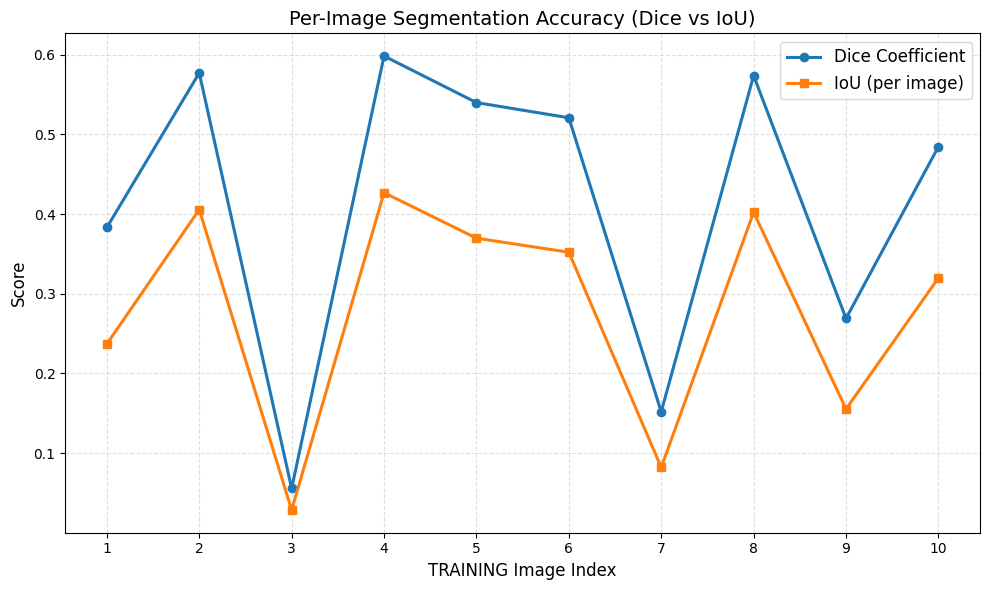

Figure: Dice and IoU plotted for each image. mIoU and mDice represent overall performance.


In [ ]:
# ============================
# CELL 4 — Final Results Table & Graphs (IoU & mIoU)
# ============================

if len(results) == 0:
    print("No results found. Run CELL 3 first.")
else:
    print("Final per-image segmentation metrics:")
    print("Note: IoU = per-image Intersection over Union, mIoU = mean IoU across dataset.\n")

    print("{:<12s} {:>10s} {:>10s}".format("Image", "Dice", "IoU"))
    print("-" * 36)

    dice_vals = []
    iou_vals  = []
    img_ids   = []

    for name, d, j in results:
        print("{:<12s} {:>10.4f} {:>10.4f}".format(name, d, j))
        img_ids.append(int(name.replace("TRAINING", "").replace(".tif", "")))
        dice_vals.append(d)
        iou_vals.append(j)

    dice_vals = np.array(dice_vals)
    iou_vals  = np.array(iou_vals)

    # ======================
    # Mean Metrics (mDice, mIoU)
    # ======================
    mDice = dice_vals.mean()
    mIoU  = iou_vals.mean()

    print("\nAverage metrics across all 10 images:")
    print(f"  Mean Dice (mDice): {mDice:.4f}")
    print(f"  Mean IoU  (mIoU ): {mIoU:.4f}")

    # Explain difference between IoU and mIoU
    print("\nExplanation:")
    print(" - IoU values above are computed per image.")
    print(" - mIoU is the mean Intersection-over-Union across the entire dataset,")
    print("   which is the required metric in the assignment brief.\n")

    # ======================
    # Graph — Dice & IoU per Image
    # ======================
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(img_ids, dice_vals, marker='o', linewidth=2.2, label='Dice Coefficient')
    ax.plot(img_ids, iou_vals, marker='s', linewidth=2.2, label='IoU (per image)')

    ax.set_xlabel("TRAINING Image Index", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Per-Image Segmentation Accuracy (Dice vs IoU)", fontsize=14)

    ax.set_xticks(img_ids)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=12)

    plt.tight_layout()
    plt.show()

    print("Figure: Dice and IoU plotted for each image. mIoU and mDice represent overall performance.")
